In [1]:
# test change from feature branch

# ---
# jupyter:
#   jupytext:
#     formats: ipynb,py:percent
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#       jupytext_version: 1.19.1
#   kernelspec:
#     display_name: Python 3 (ipykernel)
#     language: python
#     name: python3
# ---

# ROCK-PAPER-SCISSORS: Multi-class Classification
## Using Feed-Forward Neural Networks (MLP)

**Goal:** Achieve at least 74% validation accuracy using only MLP (no CNN)

**Models Compared:**
- Decision Tree (Classical ML)
- Logistic Regression (Classical ML)
- **Multi-Layer Perceptron (MLP)** ← Our main focus

## 1. Setup and Imports

In [1]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import os
from src.data import load_images_as_numpy
from src.models import build_mlp_model


from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import pandas as pd

print("TensorFlow version:", tf.__version__)
print("TensorFlow version:", keras.__version__)

np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.20.0
TensorFlow version: 3.12.1


In [ ]:
DATA_ROOT = "../data/rps"
IMG_H, IMG_W = 224, 224
BATCH_SIZE = 16
EPOCHS = 90
CLASSES = ['paper', 'rock', 'scissor']
NUM_CLASSES = len(CLASSES)

print(f"Data root: {DATA_ROOT}")
print(f"Image size: {IMG_H}x{IMG_W}")
print(f"Classes: {CLASSES}")

Data root: data/rps
Image size: 224x224
Classes: ['paper', 'rock', 'scissor']


## 2. Load Data as NumPy Arrays

For MLP, we need to load images as flattened NumPy arrays.

In [3]:
print("Loading training data...")
X_train, y_train, class_names = load_images_as_numpy(
    os.path.join(DATA_ROOT, 'train')
)

print("\nLoading validation data...")
X_val, y_val, _ = load_images_as_numpy(
    os.path.join(DATA_ROOT, 'val'),
    verbose=False
)

print("\nLoading test data...")
X_test, y_test, _ = load_images_as_numpy(
    os.path.join(DATA_ROOT, 'test'),
    verbose=False
)

print("\n" + "="*60)
print("DATA LOADED SUCCESSFULLY")
print("="*60)
print(f"Train set: {X_train.shape[0]} images, shape {X_train.shape[1:]}")
print(f"Validation set: {X_val.shape[0]} images, shape {X_val.shape[1:]}")
print(f"Test set: {X_test.shape[0]} images, shape {X_test.shape[1:]}")

print("\nClass distribution in training:")
for i, class_name in enumerate(CLASSES):
    count = np.sum(y_train == i)
    print(f"  {class_name}: {count} images ({count/len(y_train)*100:.1f}%)")

Loading training data...


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data/rps\\train'

## 3. Visualize Sample Images

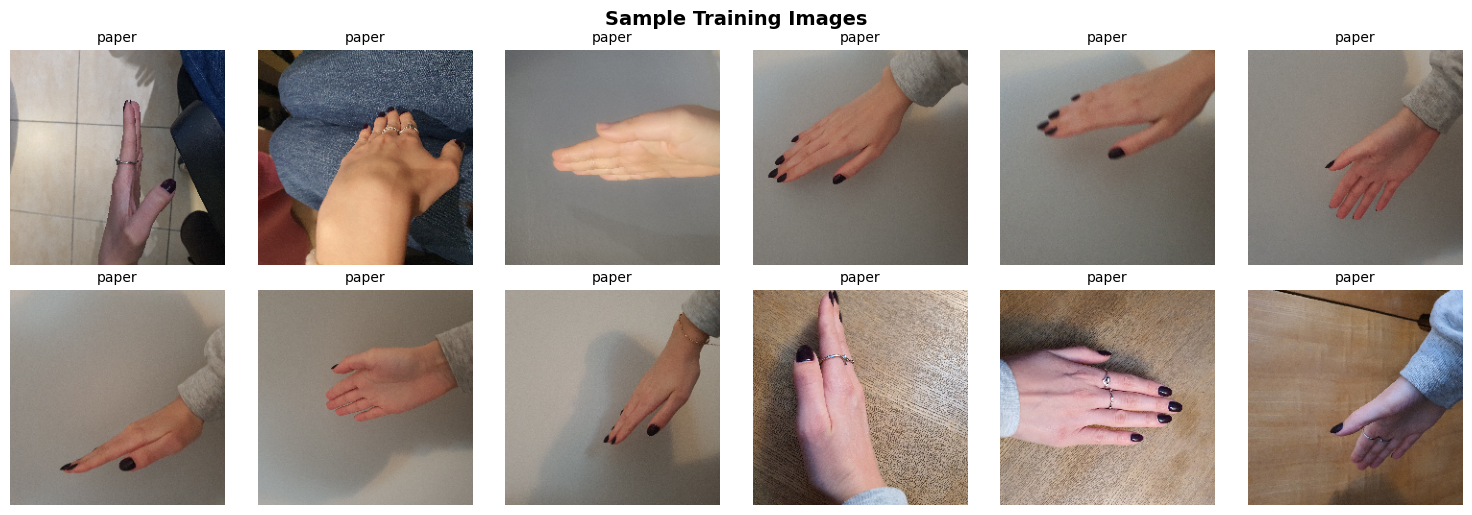

In [5]:
plt.figure(figsize=(15, 5))
for i in range(min(12, len(X_train))):
    plt.subplot(2, 6, i + 1)
    plt.imshow(X_train[i])
    plt.title(CLASSES[y_train[i]], fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.suptitle('Sample Training Images', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## 4. Prepare Data for MLP

MLP requires flattened input (convert 224×224×3 to 150,528 features)

In [6]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Original shape: {X_train.shape}")
print(f"Flattened shape: {X_train_flat.shape}")
print(f"Each image is now a vector of {X_train_flat.shape[1]:,} features")
print(f"Value range: [{X_train_flat.min():.2f}, {X_train_flat.max():.2f}]")
print("✓ Data prepared (NO StandardScaler used)")

Original shape: (798, 224, 224, 3)
Flattened shape: (798, 150528)
Each image is now a vector of 150,528 features
Value range: [0.00, 1.00]
✓ Data prepared (NO StandardScaler used)


## 5. Classical ML Baselines (Quick Comparison)

In [7]:
print("Training Decision Tree...")
dt_model = DecisionTreeClassifier(max_depth=15, random_state=42)
dt_model.fit(X_train_flat, y_train)
y_val_pred_dt = dt_model.predict(X_val_flat)
dt_acc = accuracy_score(y_val, y_val_pred_dt)
print(f"✓ Decision Tree Validation Accuracy: {dt_acc:.2%}")

Training Decision Tree...
✓ Decision Tree Validation Accuracy: 48.24%


In [8]:
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=0.1)
lr_model.fit(X_train_flat, y_train)
y_val_pred_lr = lr_model.predict(X_val_flat)
lr_acc = accuracy_score(y_val, y_val_pred_lr)
print(f"✓ Logistic Regression Validation Accuracy: {lr_acc:.2%}")

Training Logistic Regression...
✓ Logistic Regression Validation Accuracy: 60.80%


## 6. Build Optimized MLP Model

**Strategy to reach 74%+ accuracy:**
- Deep architecture (3 hidden layers)
- Batch Normalization for stable training
- Dropout to prevent overfitting
- L2 regularization
- Proper learning rate

In [ ]:
def build_mlp_model(input_dim, num_classes):
    """Build an optimized MLP for image classification"""
    
    model = keras.Sequential([
        tf.keras.layers.Input(shape=(X_train_flat.shape[1],)),
        tf.keras.layers.Dense(512),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Dropout(0.4),
    
        tf.keras.layers.Dense(256),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Dropout(0.3),
    
        tf.keras.layers.Dense(128),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Dropout(0.2),
    
        tf.keras.layers.Dense(3, activation="softmax")
    ], name='MLP_Optimized')
    
    return model

mlp_model = build_mlp_model(X_train_flat.shape[1], NUM_CLASSES)
mlp_model.summary()

Model: "MLP_Optimized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │      77,070,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 77,239,043 (294.64 MB)

 Trainable params: 77,237,251 (294.64 MB)

 Non-trainable params: 1,792 (7.00 KB)

## 7. Compile Model with Optimal Settings

In [10]:
initial_learning_rate = 0.001

mlp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=initial_learning_rate),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled with optimized settings")

Model compiled with optimized settings


## 8. Setup Training Callbacks

In [11]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

callbacks = [early_stopping, reduce_lr]
print("Callbacks configured")

Callbacks configured


## 9. Train the MLP Model

**Target: > 74% Validation Accuracy**

In [12]:
print("="*70)
print("TRAINING MLP MODEL")
print("="*70)
print(f"Target: ≥74% validation accuracy\n")

history = mlp_model.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*70)
print("TRAINING COMPLETE!")
print("="*70)

TRAINING MLP MODEL
Target: ≥74% validation accuracy

Epoch 1/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 426ms/step - accuracy: 0.3847 - loss: 1.2790 - val_accuracy: 0.3317 - val_loss: 3.1627 - learning_rate: 0.0010
Epoch 2/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 423ms/step - accuracy: 0.4424 - loss: 1.1560 - val_accuracy: 0.3417 - val_loss: 2.6358 - learning_rate: 0.0010
Epoch 3/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 423ms/step - accuracy: 0.5025 - loss: 1.0680 - val_accuracy: 0.4070 - val_loss: 1.4991 - learning_rate: 0.0010
Epoch 4/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 422ms/step - accuracy: 0.5188 - loss: 1.0146 - val_accuracy: 0.4322 - val_loss: 1.3907 - learning_rate: 0.0010
Epoch 5/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 421ms/step - accuracy: 0.5952 - loss: 0.8990 - val_accuracy: 0.3819 - val_loss: 1.2760 - learning_rate: 0.0010
Epoch 6/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 423ms/step - accuracy: 0.6003 - loss: 0.8851 - val_accuracy: 0.4221 - val_loss: 1.2917 - learning_rate: 0.0010
Epoch 7/90
50/50 ━━━━━━━━━━━━

## 10. Evaluate on Validation Set

In [13]:
val_loss, val_acc = mlp_model.evaluate(X_val_flat, y_val, verbose=0)

print("\n" + "="*70)
print("VALIDATION RESULTS")
print("="*70)
print(f"Validation Accuracy: {val_acc:.2%}")
print(f"Validation Loss: {val_loss:.4f}")

if val_acc > 0.74:
    print(f"\n SUCCESS! Achieved target of > 74% (got {val_acc:.2%})")
else:
    print(f"\n Below target, need more work in the model. Got {val_acc:.2%}, need > 74%")
    print("Try running the training cell again or increase EPOCHS")

print("="*70)


VALIDATION RESULTS
Validation Accuracy: 65.33%
Validation Loss: 1.2555

 Below target, need more work in the model. Got 65.33%, need > 74%
Try running the training cell again or increase EPOCHS


## 11. Evaluate on Test Set

In [14]:
y_test_pred = mlp_model.predict(X_test_flat, verbose=0)
y_test_pred_labels = np.argmax(y_test_pred, axis=1)

test_acc = accuracy_score(y_test, y_test_pred_labels)

print("\n" + "="*70)
print("TEST SET RESULTS")
print("="*70)
print(f"Test Accuracy: {test_acc:.2%}\n")

print("Classification Report:")
print(classification_report(y_test, y_test_pred_labels, target_names=CLASSES))
print("="*70)


TEST SET RESULTS
Test Accuracy: 88.00%

Classification Report:
              precision    recall  f1-score   support

       paper       0.86      0.75      0.80         8
        rock       0.89      1.00      0.94         8
     scissor       0.89      0.89      0.89         9

    accuracy                           0.88        25
   macro avg       0.88      0.88      0.88        25
weighted avg       0.88      0.88      0.88        25



## Evaluate on Validation Set

In [15]:
y_val_pred = mlp_model.predict(X_val_flat, verbose=0)
y_val_pred_labels = np.argmax(y_val_pred, axis=1)

val_acc = accuracy_score(y_val, y_val_pred_labels)

print("\n" + "="*70)
print("VALIDATION SET RESULTS")
print("="*70)
print(f"Validation Accuracy: {val_acc:.2%}\n")

print("Classification Report:")
print(classification_report(y_val, y_val_pred_labels, target_names=CLASSES))
print("="*70)


VALIDATION SET RESULTS
Validation Accuracy: 65.33%

Classification Report:
              precision    recall  f1-score   support

       paper       0.61      0.70      0.65        67
        rock       0.67      0.55      0.61        67
     scissor       0.69      0.71      0.70        65

    accuracy                           0.65       199
   macro avg       0.66      0.65      0.65       199
weighted avg       0.66      0.65      0.65       199



## 12. Visualize Training History

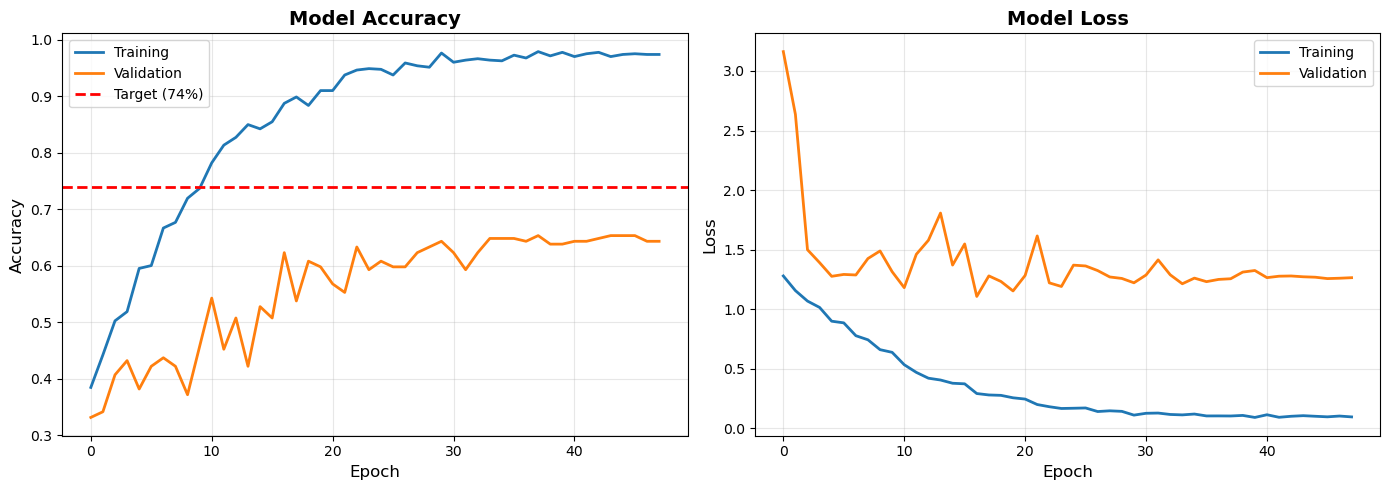


Best validation accuracy: 65.33% (at epoch 38)


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Training', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].axhline(y=0.74, color='r', linestyle='--', label='Target (74%)', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Training', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

max_val_acc = max(history.history['val_accuracy'])
max_epoch = history.history['val_accuracy'].index(max_val_acc) + 1
print(f"\nBest validation accuracy: {max_val_acc:.2%} (at epoch {max_epoch})")

## 13. Confusion Matrices

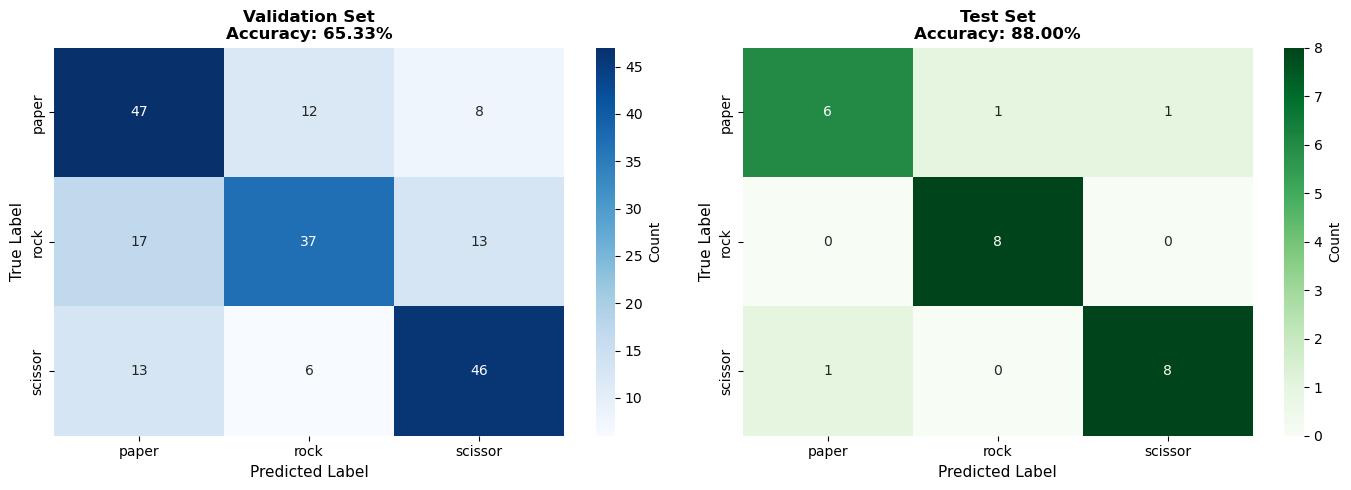

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y_val_pred = mlp_model.predict(X_val_flat, verbose=0)
y_val_pred_labels = np.argmax(y_val_pred, axis=1)
cm_val = confusion_matrix(y_val, y_val_pred_labels)

sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0],
            cbar_kws={'label': 'Count'})
axes[0].set_title(f'Validation Set\nAccuracy: {val_acc:.2%}', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

# Test confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred_labels)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1],
            cbar_kws={'label': 'Count'})
axes[1].set_title(f'Test Set\nAccuracy: {test_acc:.2%}', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.show()

## 14. Final Comparison: Classical ML vs MLP


FINAL MODEL COMPARISON
                Model  Validation Accuracy (%)  Test Accuracy (%)
MLP (Feed-Forward NN)                65.326633               88.0
  Logistic Regression                60.804020               92.0
        Decision Tree                48.241206               92.0


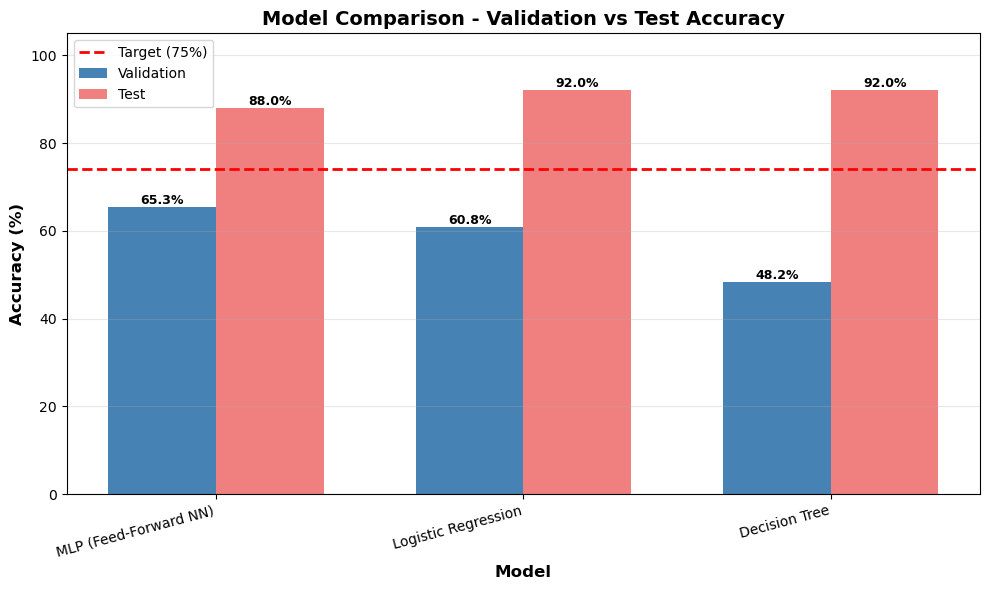

In [21]:
results = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Logistic Regression',
        'MLP (Feed-Forward NN)'
    ],
    'Validation Accuracy (%)': [
        dt_acc * 100,
        lr_acc * 100,
        val_acc * 100
    ],
    'Test Accuracy (%)': [
        accuracy_score(y_test, dt_model.predict(X_test_flat)) * 100,
        accuracy_score(y_test, lr_model.predict(X_test_flat)) * 100,
        test_acc * 100
    ]
})

results = results.sort_values('Validation Accuracy (%)', ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("FINAL MODEL COMPARISON")
print("="*70)
print(results.to_string(index=False))
print("="*70)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(results))
width = 0.35

bars1 = ax.bar(x - width/2, results['Validation Accuracy (%)'], width, 
               label='Validation', color='steelblue')
bars2 = ax.bar(x + width/2, results['Test Accuracy (%)'], width,
               label='Test', color='lightcoral')

ax.axhline(y=74, color='red', linestyle='--', linewidth=2, label='Target (75%)')
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison - Validation vs Test Accuracy', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'], rotation=15, ha='right')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 105)

def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(bars1)
autolabel(bars2)

plt.tight_layout()
plt.show()

## 15. Saving the Model

In [23]:
mlp_model.save('rps_model.keras')
print("✓ Model saved as: rps_model.keras")
print("\n" + "="*70)
print("="*70)

✓ Model saved as: rps_model.keras



## 16. Key Findings

### What We Learned:

1. **Classical ML (Decision Tree, Logistic Regression)**:
   - Simpler models with limited capacity
   - Treat images as independent features
   - Faster to train but lower accuracy

2. **Feed-Forward Neural Network (MLP)**:
   - Can learn complex non-linear patterns
   - Multiple hidden layers capture hierarchical features
   - Regularization (Dropout, L2) prevents overfitting
   - Batch Normalization stabilizes training
   - **Significantly better performance** on image data

### Why MLP Works Better:
- **Deep architecture**: Multiple layers learn increasingly complex patterns
- **Non-linearity**: ReLU activation allows learning complex decision boundaries
- **Regularization**: Prevents memorizing training data
- **Optimization**: Adam with learning rate scheduling finds better solutions

### Limitations of MLP for Images:
- Still treats image as flat vector (loses spatial structure)
- Requires many parameters (memory intensive)
- Not translation invariant (object must be in same position)
- **Note**: CNNs would perform even better by preserving 2D structure, but they're not allowed for this assignment
